# Синтетические данные с управляемой причинной структурой

Notebook реализует три сценария генерации синтетических временных рядов с известной причинно-следственной структурой для валидации методов каузального вывода.

**Сценарии:**
1. Линейная VAR-модель с известной матрицей влияния
2. Нелинейный процесс с пороговым эффектом (SETAR)
3. Многомерная система с латентным конфаундером

## 0. Импорты и утилиты

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Воспроизводимость
GLOBAL_SEED = 42
rng = np.random.default_rng(GLOBAL_SEED)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'lines.linewidth': 1.5,
})

print('Библиотеки загружены. Версии:')
print(f'  numpy  {np.__version__}')
print(f'  pandas {pd.__version__}')

Библиотеки загружены. Версии:
  numpy  2.2.2
  pandas 2.2.3


---
## 1. Сценарий 1: Линейная VAR-модель с известным каузальным эффектом

### Структурные уравнения

$$C_t = 0.6 \cdot C_{t-1} + \varepsilon_{C,t}$$
$$X_t = 0.3 \cdot X_{t-1} + 0.4 \cdot C_{t-1} + \varepsilon_{X,t}$$
$$Y_t = 0.2 \cdot Y_{t-1} + \underbrace{0.8}_{\text{истинный эффект}} \cdot X_{t-1} - 0.3 \cdot C_{t-1} + \varepsilon_{Y,t}$$

**Истинный каузальный эффект** $X \rightarrow Y$ = **0.8**

В момент $t_0 = 300$ производится вмешательство: $X_{t_0}$ увеличивается на $\Delta = +2$ стандартных отклонения.

In [2]:
def generate_scenario1(
    T: int = 500,
    t0: int = 250,
    delta_sigma: float = 2.0,
    seed: int = 42,
    sigma: float = 1.0,
) -> dict:
    """
    Сценарий 1: Линейная VAR(1) модель с конфаундером.

    Параметры
    ---------
    T            : длина ряда
    t0           : момент вмешательства
    delta_sigma  : величина шока в единицах std(X)
    seed         : seed для воспроизводимости
    sigma        : масштаб шумов

    Возвращает
    ----------
    dict с ключами:
        'df'              : DataFrame (Y, X, C)
        'df_counterfactual': DataFrame без вмешательства
        'true_effect'     : истинный коэффициент X -> Y
        't0'              : момент вмешательства
        'delta'           : величина шока в исходных единицах
    """
    rng = np.random.default_rng(seed)

    # --- коэффициенты ---
    a_C = 0.6   # C_t = a_C * C_{t-1} + eps
    a_X = 0.3   # X_t = a_X * X_{t-1} + ...
    b_XC = 0.4  # влияние C на X
    a_Y = 0.2   # Y_t = a_Y * Y_{t-1} + ...
    b_YX = 0.8  # ИСТИННЫЙ КАУЗАЛЬНЫЙ ЭФФЕКТ
    b_YC = -0.3 # влияние C на Y (прямое)
    TRUE_EFFECT = b_YX

    # --- шумы ---
    eps_C = rng.normal(0, sigma, T)
    eps_X = rng.normal(0, sigma, T)
    eps_Y = rng.normal(0, sigma, T)

    # --- генерация без вмешательства (контрфактуал) ---
    C_cf = np.zeros(T)
    X_cf = np.zeros(T)
    Y_cf = np.zeros(T)

    for t in range(1, T):
        C_cf[t] = a_C * C_cf[t-1] + eps_C[t]
        X_cf[t] = a_X * X_cf[t-1] + b_XC * C_cf[t-1] + eps_X[t]
        Y_cf[t] = a_Y * Y_cf[t-1] + b_YX * X_cf[t-1] + b_YC * C_cf[t-1] + eps_Y[t]

    # величина шока
    delta = delta_sigma * np.std(X_cf)

    # --- генерация с вмешательством ---
    C = C_cf.copy()
    X = X_cf.copy()
    Y = np.zeros(T)

    for t in range(1, T):
        Y[t] = a_Y * Y[t-1] + b_YX * X[t-1] + b_YC * C[t-1] + eps_Y[t]
        if t == t0:
            X[t] += delta  # вмешательство

    idx = pd.RangeIndex(T, name='t')
    df = pd.DataFrame({'Y': Y, 'X': X, 'C': C}, index=idx)
    df_cf = pd.DataFrame({'Y': Y_cf, 'X': X_cf, 'C': C_cf}, index=idx)

    return {
        'df': df,
        'df_counterfactual': df_cf,
        'true_effect': TRUE_EFFECT,
        't0': t0,
        'delta': delta,
        'params': dict(a_C=a_C, a_X=a_X, b_XC=b_XC, a_Y=a_Y, b_YX=b_YX, b_YC=b_YC),
    }


# --- генерация ---
res1 = generate_scenario1(T=600, t0=300, seed=GLOBAL_SEED)
df1, df1_cf = res1['df'], res1['df_counterfactual']

print('Сценарий 1 сгенерирован.')
print(f"  Длина ряда      : {len(df1)}")
print(f"  Момент шока     : t0 = {res1['t0']}")
print(f"  Величина шока   : Δ = {res1['delta']:.4f}")
print(f"  Истинный эффект : θ = {res1['true_effect']}")
print()
df1.describe().round(3)

Сценарий 1 сгенерирован.
  Длина ряда      : 600
  Момент шока     : t0 = 300
  Величина шока   : Δ = 2.5503
  Истинный эффект : θ = 0.8



,Y,X,C
count,600.000,600.000,600.000
mean,-0.130,-0.057,-0.063
std,1.533,1.278,1.245
min,-5.345,-4.517,-4.018
25%,-1.167,-0.878,-0.933
50%,-0.174,-0.013,-0.051
75%,0.905,0.790,0.772
max,4.785,3.995,4.208


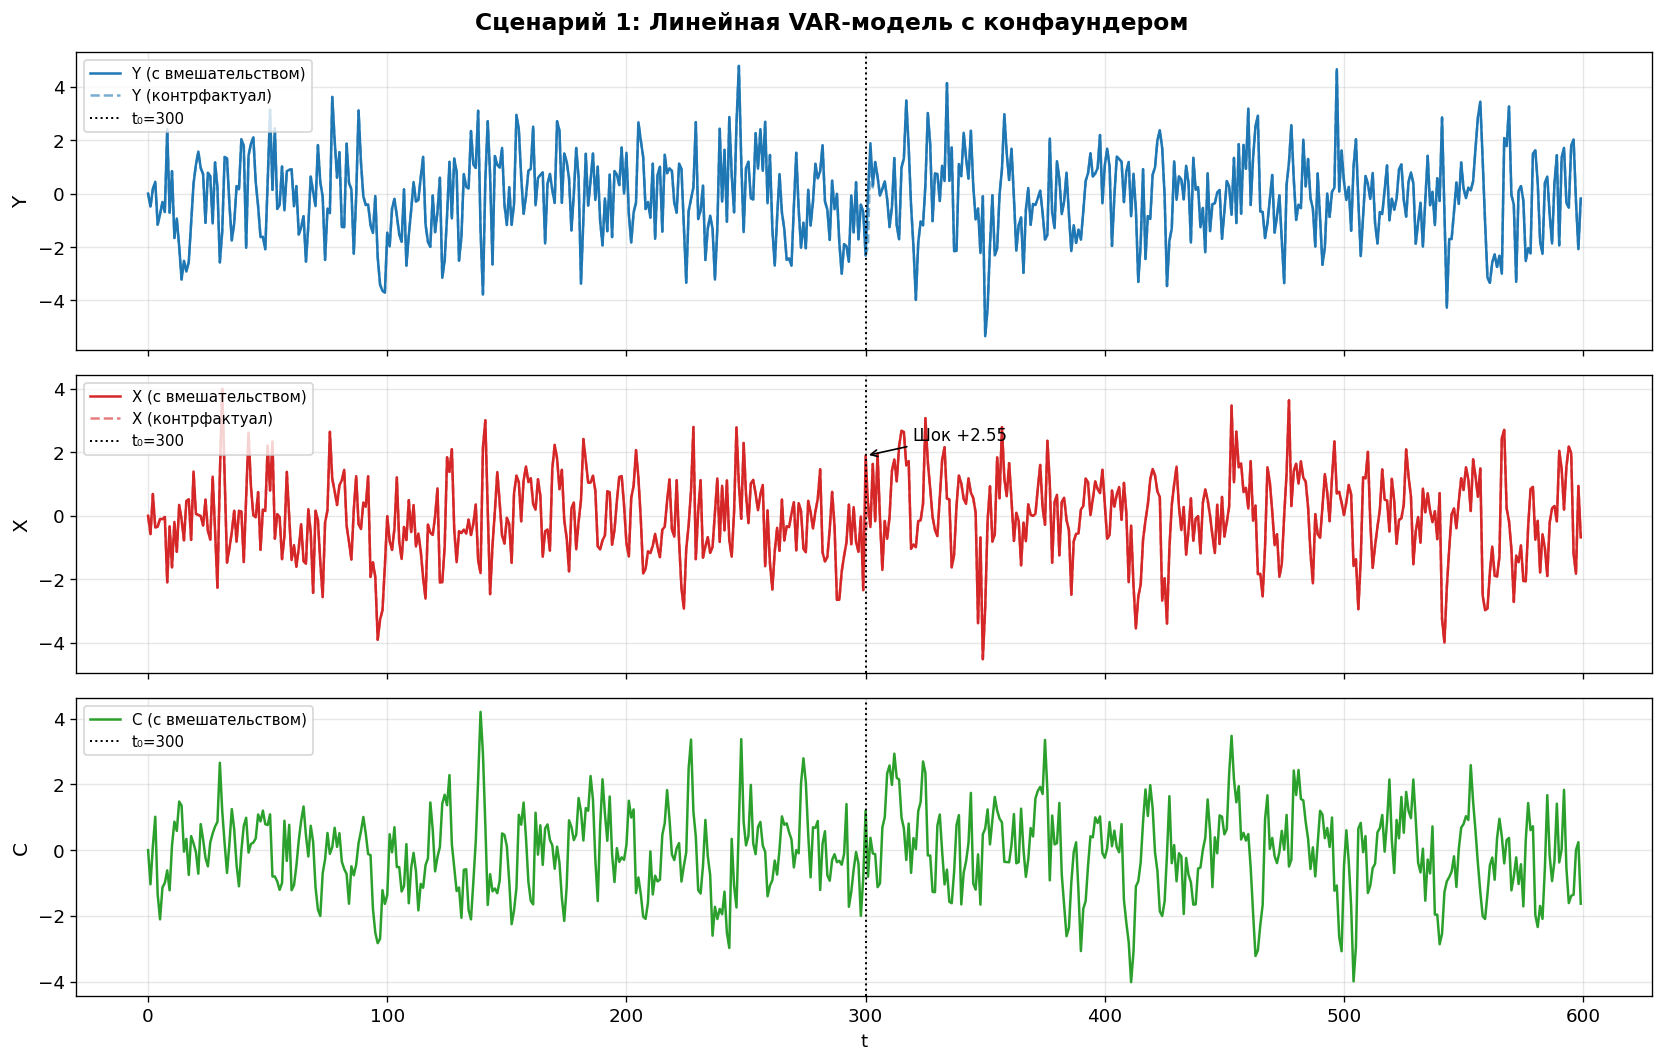

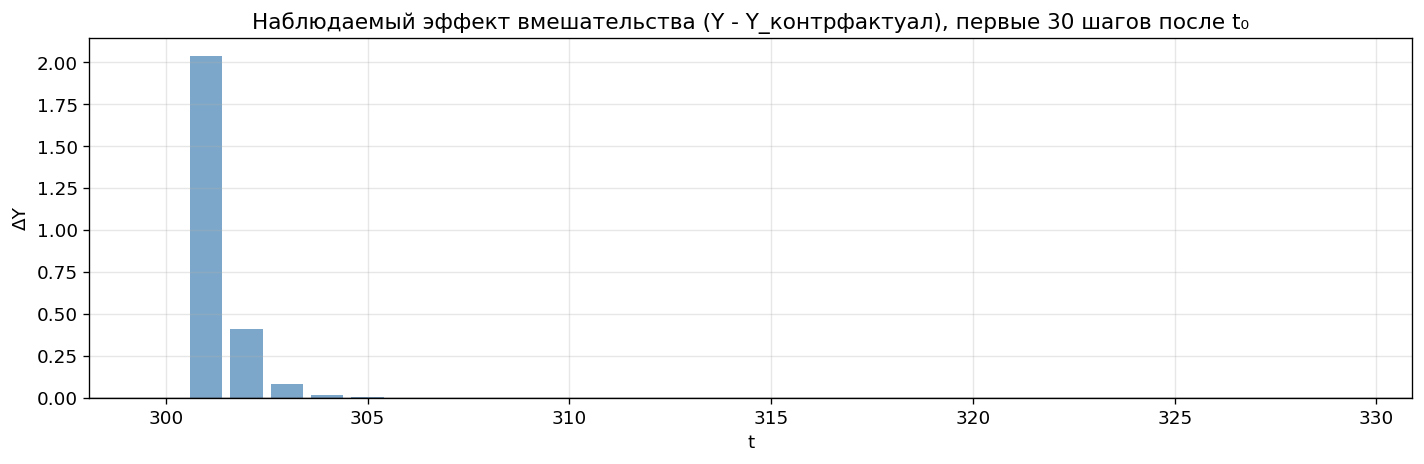

In [3]:
def plot_scenario1(res: dict):
    df    = res['df']
    df_cf = res['df_counterfactual']
    t0    = res['t0']
    delta = res['delta']

    fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    fig.suptitle('Сценарий 1: Линейная VAR-модель с конфаундером', fontsize=14, fontweight='bold')

    colors = {'Y': '#1f77b4', 'X': '#d62728', 'C': '#2ca02c'}

    for ax, var in zip(axes, ['Y', 'X', 'C']):
        ax.plot(df.index, df[var], color=colors[var], label=f'{var} (с вмешательством)', lw=1.5)
        if var != 'C':  # C не меняется
            ax.plot(df_cf.index, df_cf[var], color=colors[var], ls='--', alpha=0.6,
                    label=f'{var} (контрфактуал)')
        ax.axvline(t0, color='black', ls=':', lw=1.2, label=f't₀={t0}')
        if var == 'X':
            ax.annotate(f'Шок +{delta:.2f}', xy=(t0, df.loc[t0, 'X']),
                        xytext=(t0+20, df.loc[t0, 'X']+0.5),
                        arrowprops=dict(arrowstyle='->', color='black'),
                        fontsize=10)
        ax.set_ylabel(var, fontsize=12)
        ax.legend(loc='upper left', fontsize=9)
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel('t')
    plt.tight_layout()
    plt.show()

    # Эффект вмешательства: разница Y - Y_cf после t0
    fig2, ax2 = plt.subplots(figsize=(12, 4))
    effect = df['Y'] - df_cf['Y']
    ax2.bar(df.index[t0:t0+30], effect[t0:t0+30], color='steelblue', alpha=0.7)
    ax2.axhline(0, color='black', lw=0.8)
    ax2.set_title('Наблюдаемый эффект вмешательства (Y - Y_контрфактуал), первые 30 шагов после t₀')
    ax2.set_xlabel('t')
    ax2.set_ylabel('ΔY')
    ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_scenario1(res1)

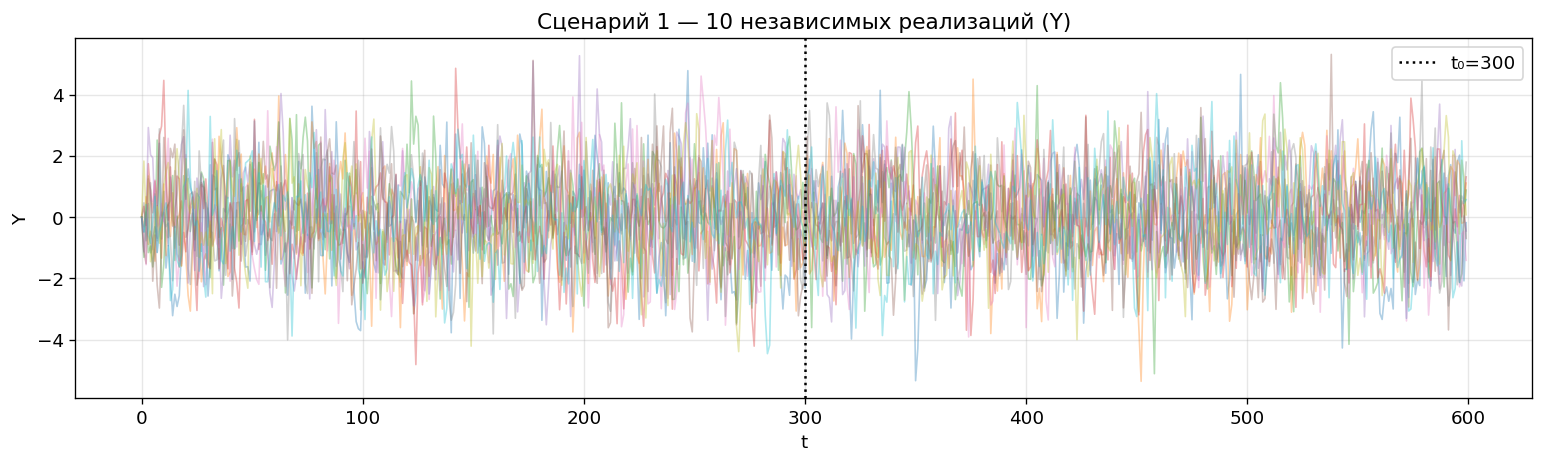

Сгенерировано 10 реализаций. Истинный эффект = 0.8


In [4]:
# Множественные реализации (10 независимых seed-ов)
def generate_multiple_realizations_s1(n_real=10, T=600, t0=300):
    results = []
    for i in range(n_real):
        r = generate_scenario1(T=T, t0=t0, seed=GLOBAL_SEED + i)
        results.append(r)
    return results

realizations_s1 = generate_multiple_realizations_s1(n_real=10)

fig, ax = plt.subplots(figsize=(13, 4))
for r in realizations_s1:
    ax.plot(r['df'].index, r['df']['Y'], alpha=0.35, lw=1)
ax.axvline(300, color='black', ls=':', lw=1.5, label='t₀=300')
ax.set_title('Сценарий 1 — 10 независимых реализаций (Y)')
ax.set_xlabel('t'); ax.set_ylabel('Y')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'Сгенерировано {len(realizations_s1)} реализаций. Истинный эффект = {realizations_s1[0]["true_effect"]}')

---
## 2. Сценарий 2: Нелинейный процесс с пороговым эффектом (SETAR)

### Пороговое уравнение

$$Y_t = \begin{cases}
0.1 + 0.5 \cdot X_{t-1} + \varepsilon_t & \text{если } |X_{t-1}| < 1 \quad (\text{низкая волатильность})\\
0.1 + 1.5 \cdot X_{t-1} + \varepsilon_t & \text{если } |X_{t-1}| \geq 1 \quad (\text{высокая волатильность})
\end{cases}$$

**Истинный каузальный эффект:** 0.5 (низкая волатильность) и 1.5 (высокая волатильность)

$X_t$ генерируется как AR(1) с GARCH-подобной гетероскедастичностью.

In [5]:
def generate_scenario2(
    T: int = 600,
    threshold: float = 1.0,
    beta_low: float = 0.5,
    beta_high: float = 1.5,
    intercept: float = 0.1,
    ar_x: float = 0.7,
    seed: int = 42,
) -> dict:
    """
    Сценарий 2: SETAR-модель с пороговым причинным эффектом.

    X_t  генерируется как AR(1) + GARCH(1,1)-подобный шум.
    Z_t  — наблюдаемый конфаундер (коррелирован с X и Y).
    Y_t  — целевой ряд с пороговым эффектом.

    Возвращает dict с ключами: 'df', 'threshold', 'beta_low',
    'beta_high', 'regime' (массив 0/1)
    """
    rng = np.random.default_rng(seed)

    # --- генерация X с GARCH-подобной волатильностью ---
    h = np.ones(T)           # условная дисперсия
    omega, alpha_g, beta_g = 0.05, 0.15, 0.80  # GARCH(1,1) параметры
    X = np.zeros(T)
    eps_x = rng.standard_normal(T)

    for t in range(1, T):
        h[t] = omega + alpha_g * (X[t-1]**2) + beta_g * h[t-1]
        X[t] = ar_x * X[t-1] + np.sqrt(h[t]) * eps_x[t]

    # --- конфаундер Z: коррелирован с X ---
    Z = np.zeros(T)
    eps_z = rng.standard_normal(T)
    for t in range(1, T):
        Z[t] = 0.5 * Z[t-1] + 0.4 * X[t-1] + 0.3 * eps_z[t]

    # --- генерация Y с пороговым эффектом ---
    Y = np.zeros(T)
    regime = np.zeros(T, dtype=int)   # 0 = низкая, 1 = высокая волатильность
    eps_y = rng.standard_normal(T)

    for t in range(1, T):
        if abs(X[t-1]) < threshold:
            beta = beta_low
            regime[t] = 0
        else:
            beta = beta_high
            regime[t] = 1
        Y[t] = intercept + beta * X[t-1] + 0.15 * Z[t-1] + eps_y[t]

    # --- волатильность X как дополнительная наблюдаемая переменная ---
    vol_X = pd.Series(X).rolling(10, min_periods=1).std().values

    idx = pd.RangeIndex(T, name='t')
    df = pd.DataFrame({'Y': Y, 'X': X, 'Z': Z, 'vol_X': vol_X, 'regime': regime}, index=idx)

    return {
        'df': df,
        'threshold': threshold,
        'beta_low': beta_low,
        'beta_high': beta_high,
        'regime': regime,
        'h': h,  # условная дисперсия
    }


res2 = generate_scenario2(T=600, seed=GLOBAL_SEED)
df2 = res2['df']

n_high = (df2['regime'] == 1).sum()
n_low  = (df2['regime'] == 0).sum()

print('Сценарий 2 сгенерирован.')
print(f"  Длина ряда               : {len(df2)}")
print(f"  Порог                    : |X_{{t-1}}| = {res2['threshold']}")
print(f"  β (низкая волатильность) : {res2['beta_low']}")
print(f"  β (высокая волатильность): {res2['beta_high']}")
print(f"  Наблюдений в режиме 0    : {n_low} ({100*n_low/len(df2):.1f}%)")
print(f"  Наблюдений в режиме 1    : {n_high} ({100*n_high/len(df2):.1f}%)")
print()
df2.describe().round(3)

Сценарий 2 сгенерирован.
  Длина ряда               : 600
  Порог                    : |X_{t-1}| = 1.0
  β (низкая волатильность) : 0.5
  β (высокая волатильность): 1.5
  Наблюдений в режиме 0    : 144 (24.0%)
  Наблюдений в режиме 1    : 456 (76.0%)



,Y,X,Z,vol_X,regime
count,600.000,600.000,600.000,599.000,600.000
mean,-1.664,-1.109,-0.833,9.680,0.760
std,25.362,16.415,10.174,11.017,0.427
min,-138.053,-87.754,-54.373,0.306,0.000
25%,-6.271,-4.539,-2.255,2.189,1.000
50%,-0.049,-0.058,-0.030,5.248,1.000
75%,6.101,4.182,2.440,12.501,1.000
max,121.578,78.177,41.857,57.744,1.000


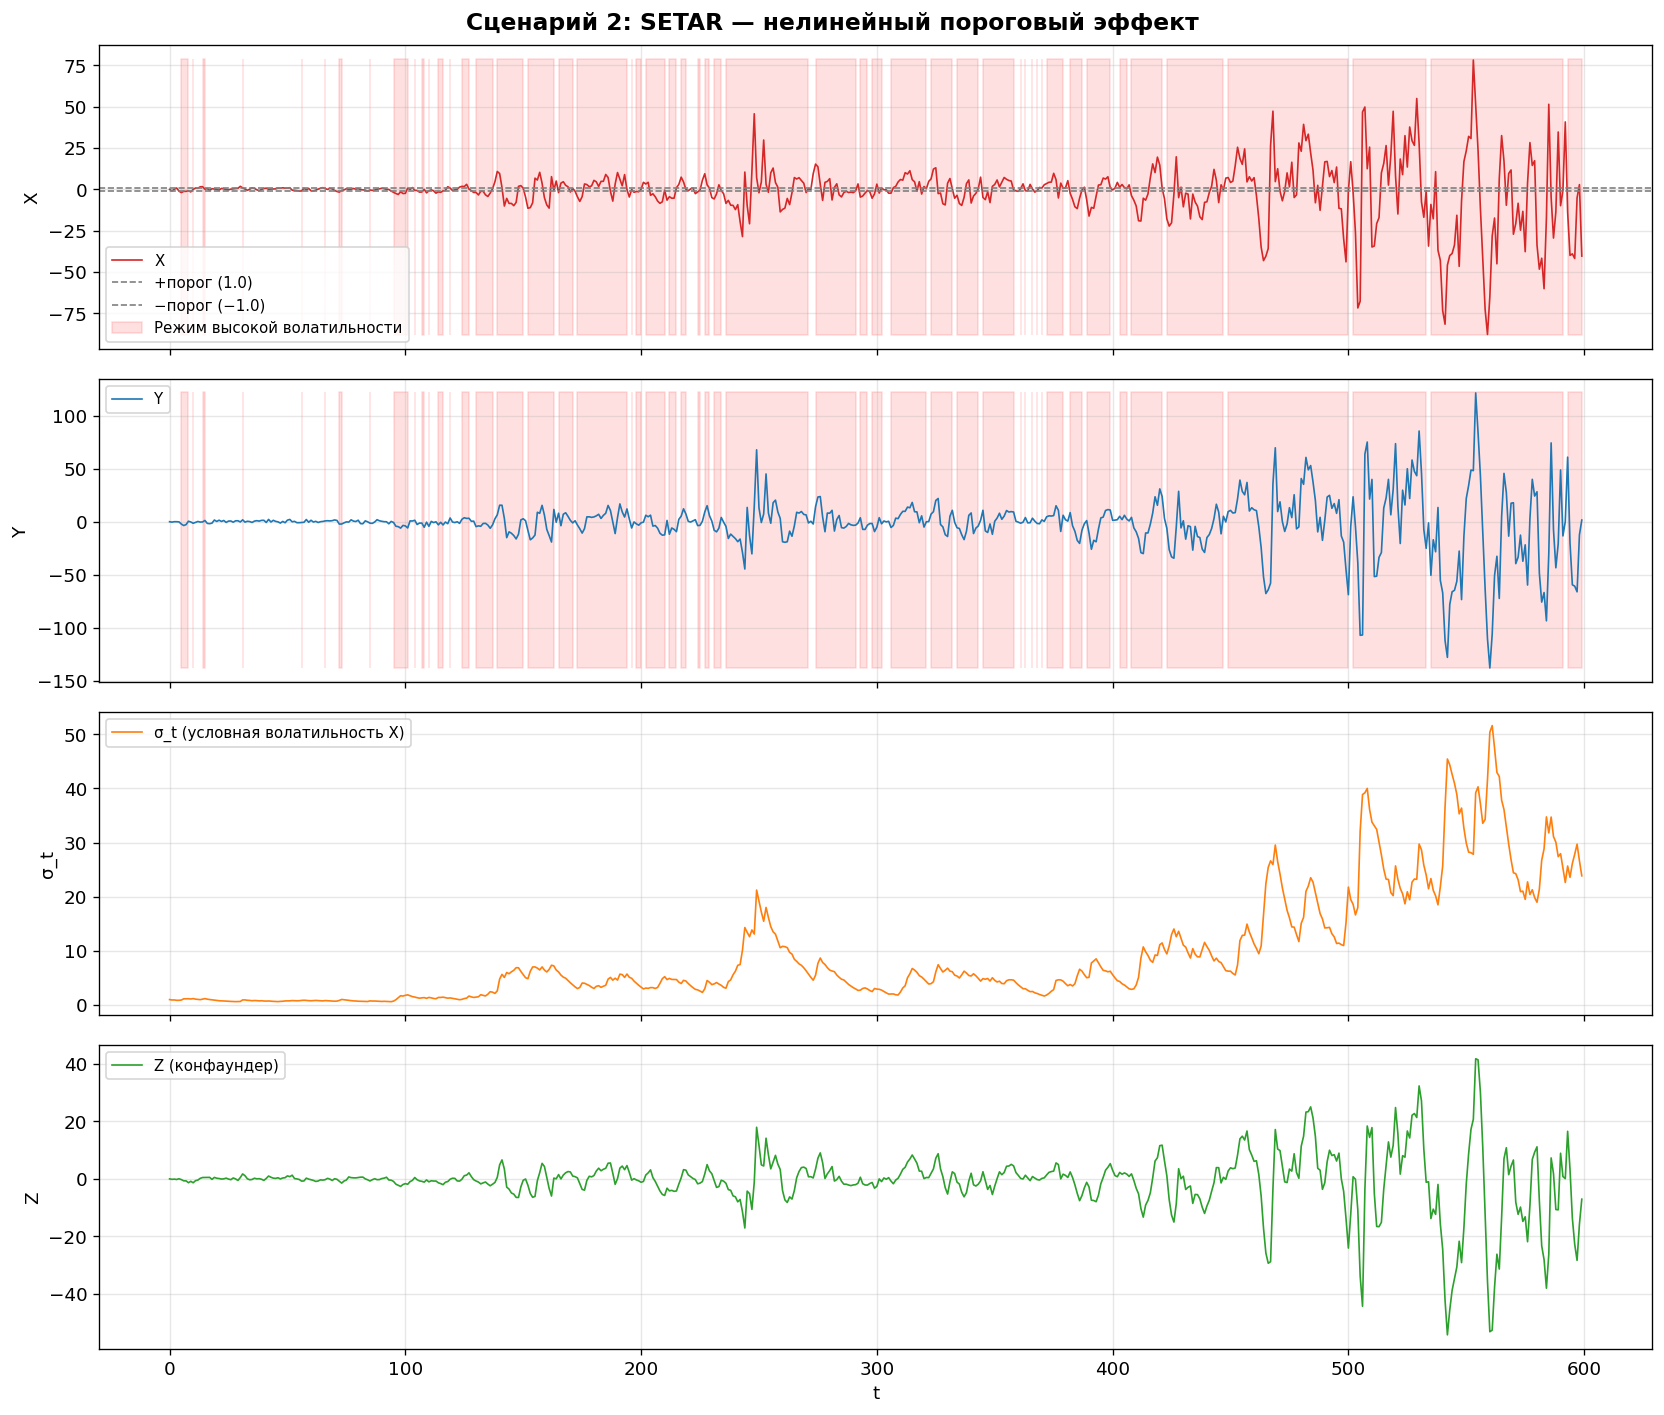

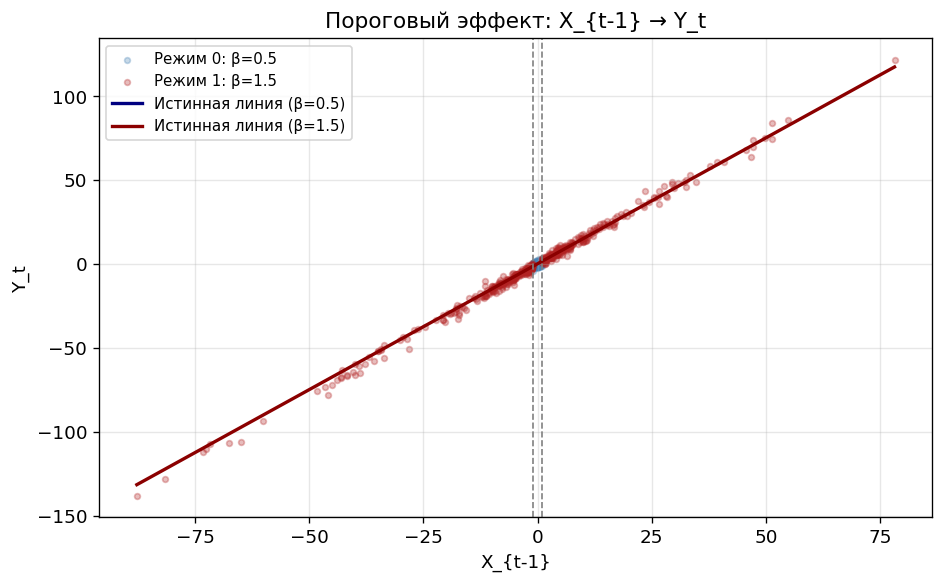

In [6]:
def plot_scenario2(res: dict):
    df     = res['df']
    thresh = res['threshold']
    h      = res['h']

    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    fig.suptitle('Сценарий 2: SETAR — нелинейный пороговый эффект', fontsize=14, fontweight='bold')

    # X с выделением режимов
    ax = axes[0]
    regime_mask = df['regime'].astype(bool)
    ax.plot(df.index, df['X'], color='#d62728', lw=1, label='X')
    ax.axhline(thresh, color='gray', ls='--', lw=1, label=f'+порог ({thresh})')
    ax.axhline(-thresh, color='gray', ls='--', lw=1, label=f'−порог (−{thresh})')
    ax.fill_between(df.index, df['X'].min()-0.5, df['X'].max()+0.5,
                    where=regime_mask, alpha=0.12, color='red', label='Режим высокой волатильности')
    ax.set_ylabel('X'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

    # Y
    axes[1].plot(df.index, df['Y'], color='#1f77b4', lw=1, label='Y')
    axes[1].fill_between(df.index, df['Y'].min()-0.5, df['Y'].max()+0.5,
                         where=regime_mask, alpha=0.12, color='red')
    axes[1].set_ylabel('Y'); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

    # Условная дисперсия (GARCH)
    axes[2].plot(df.index, np.sqrt(h), color='#ff7f0e', lw=1, label='σ_t (условная волатильность X)')
    axes[2].set_ylabel('σ_t'); axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

    # Конфаундер Z
    axes[3].plot(df.index, df['Z'], color='#2ca02c', lw=1, label='Z (конфаундер)')
    axes[3].set_ylabel('Z'); axes[3].set_xlabel('t')
    axes[3].legend(fontsize=9); axes[3].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Scatter: X_{t-1} vs Y_t по режимам
    fig2, ax2 = plt.subplots(figsize=(8, 5))
    mask0 = df['regime'] == 0
    mask1 = df['regime'] == 1
    x_lag = df['X'].shift(1).values
    ax2.scatter(x_lag[mask0], df['Y'].values[mask0], alpha=0.3, s=12,
                color='steelblue', label=f'Режим 0: β={res["beta_low"]}')
    ax2.scatter(x_lag[mask1], df['Y'].values[mask1], alpha=0.3, s=12,
                color='firebrick', label=f'Режим 1: β={res["beta_high"]}')

    # Линии регрессии
    xg = np.linspace(x_lag[~np.isnan(x_lag)].min(), x_lag[~np.isnan(x_lag)].max(), 100)
    ax2.plot(xg[abs(xg) < 1], 0.1 + res['beta_low'] * xg[abs(xg) < 1],
             color='navy', lw=2, label=f'Истинная линия (β={res["beta_low"]})')
    ax2.plot(xg[abs(xg) >= 1], 0.1 + res['beta_high'] * xg[abs(xg) >= 1],
             color='darkred', lw=2, label=f'Истинная линия (β={res["beta_high"]})')

    ax2.axvline(-1, color='gray', ls='--', lw=1)
    ax2.axvline(1, color='gray', ls='--', lw=1)
    ax2.set_xlabel('X_{t-1}'); ax2.set_ylabel('Y_t')
    ax2.set_title('Пороговый эффект: X_{t-1} → Y_t')
    ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_scenario2(res2)

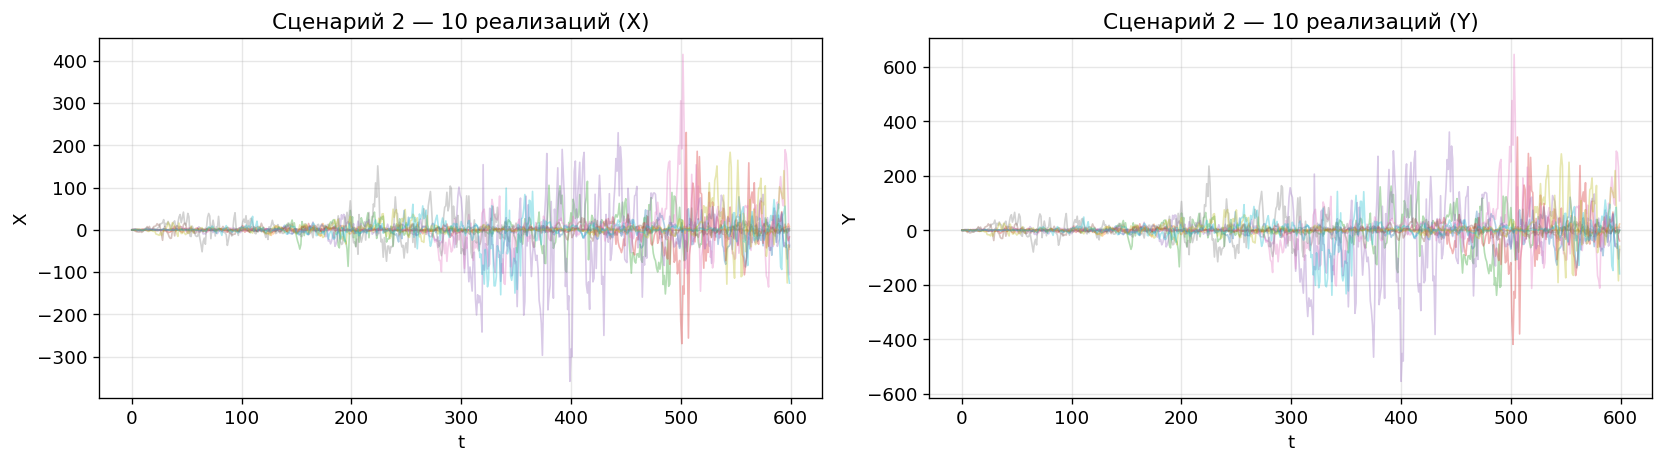

Сгенерировано 10 реализаций.


In [7]:
# Множественные реализации
realizations_s2 = [generate_scenario2(T=600, seed=GLOBAL_SEED + i) for i in range(10)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for r in realizations_s2:
    axes[0].plot(r['df'].index, r['df']['X'], alpha=0.35, lw=1)
    axes[1].plot(r['df'].index, r['df']['Y'], alpha=0.35, lw=1)
for ax, var in zip(axes, ['X', 'Y']):
    ax.set_title(f'Сценарий 2 — 10 реализаций ({var})')
    ax.set_xlabel('t'); ax.set_ylabel(var); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Сгенерировано {len(realizations_s2)} реализаций.')

---
## 3. Сценарий 3: Многомерная система с латентным конфаундером

### Структурные уравнения

$$U_t \sim AR(1) \quad \text{(скрытый процесс)}$$
$$X_t = 0.3 \cdot U_t + 0.5 \cdot X_{t-1} + \varepsilon_{X,t}$$
$$Y_t = \underbrace{0.7}_{\text{истинный эффект}} \cdot X_{t-1} + 0.4 \cdot U_t + 0.2 \cdot Y_{t-1} + \varepsilon_{Y,t}$$

**Истинный каузальный эффект** $X \rightarrow Y$ = **0.7**

$U_t$ — **ненаблюдаем**. $W_t$ — наблюдаемый прокси (скользящая волатильность X).

In [8]:
def generate_scenario3(
    T: int = 600,
    seed: int = 42,
    ar_U: float = 0.8,
    coef_UX: float = 0.3,
    ar_X: float = 0.5,
    coef_XY: float = 0.7,   # ИСТИННЫЙ КАУЗАЛЬНЫЙ ЭФФЕКТ
    coef_UY: float = 0.4,
    ar_Y: float = 0.2,
    sigma: float = 1.0,
    proxy_window: int = 10,
) -> dict:
    """
    Сценарий 3: Многомерная система с латентным конфаундером U_t.

    U_t  — латентный (ненаблюдаемый) AR(1)-конфаундер.
    X_t  — наблюдаемая причина, зависит от U_t.
    Y_t  — целевой ряд.
    W_t  — прокси: скользящая волатильность X (наблюдаемая).

    Возвращает
    ----------
    dict с 'df_observed' (Y, X, W), 'df_full' (+ U), 'true_effect'
    """
    rng = np.random.default_rng(seed)
    TRUE_EFFECT = coef_XY

    eps_U = rng.normal(0, sigma * 0.5, T)
    eps_X = rng.normal(0, sigma, T)
    eps_Y = rng.normal(0, sigma, T)

    U = np.zeros(T)
    X = np.zeros(T)
    Y = np.zeros(T)

    for t in range(1, T):
        U[t] = ar_U * U[t-1] + eps_U[t]
        X[t] = coef_UX * U[t] + ar_X * X[t-1] + eps_X[t]
        Y[t] = coef_XY * X[t-1] + coef_UY * U[t] + ar_Y * Y[t-1] + eps_Y[t]

    # Прокси W: скользящая волатильность X (наблюдаемая)
    W = pd.Series(X).rolling(proxy_window, min_periods=1).std().fillna(0).values

    idx = pd.RangeIndex(T, name='t')
    df_observed = pd.DataFrame({'Y': Y, 'X': X, 'W': W}, index=idx)
    df_full     = pd.DataFrame({'Y': Y, 'X': X, 'W': W, 'U': U}, index=idx)

    # Корреляции для диагностики
    corr_UX = np.corrcoef(U[1:], X[1:])[0, 1]
    corr_UY = np.corrcoef(U[1:], Y[1:])[0, 1]
    corr_WU = np.corrcoef(W[1:], U[1:])[0, 1]

    return {
        'df_observed': df_observed,
        'df_full': df_full,
        'true_effect': TRUE_EFFECT,
        'corr_UX': corr_UX,
        'corr_UY': corr_UY,
        'corr_WU': corr_WU,
        'params': dict(ar_U=ar_U, coef_UX=coef_UX, ar_X=ar_X,
                       coef_XY=coef_XY, coef_UY=coef_UY, ar_Y=ar_Y),
    }


res3 = generate_scenario3(T=600, seed=GLOBAL_SEED)
df3_obs  = res3['df_observed']
df3_full = res3['df_full']

print('Сценарий 3 сгенерирован.')
print(f"  Истинный каузальный эффект  : θ = {res3['true_effect']}")
print(f"  Корреляция U и X            : {res3['corr_UX']:.3f}")
print(f"  Корреляция U и Y            : {res3['corr_UY']:.3f}")
print(f"  Корреляция прокси W и U     : {res3['corr_WU']:.3f}")
print()
print('Наблюдаемые переменные (без U):')
df3_obs.describe().round(3)

Сценарий 3 сгенерирован.
  Истинный каузальный эффект  : θ = 0.7
  Корреляция U и X            : 0.267
  Корреляция U и Y            : 0.343
  Корреляция прокси W и U     : -0.003

Наблюдаемые переменные (без U):


,Y,X,W
count,600.000,600.000,600.000
mean,-0.189,-0.073,1.073
std,1.591,1.274,0.339
min,-5.170,-4.339,0.000
25%,-1.208,-0.898,0.821
50%,-0.109,-0.056,1.041
75%,0.951,0.849,1.279
max,4.017,3.322,2.231


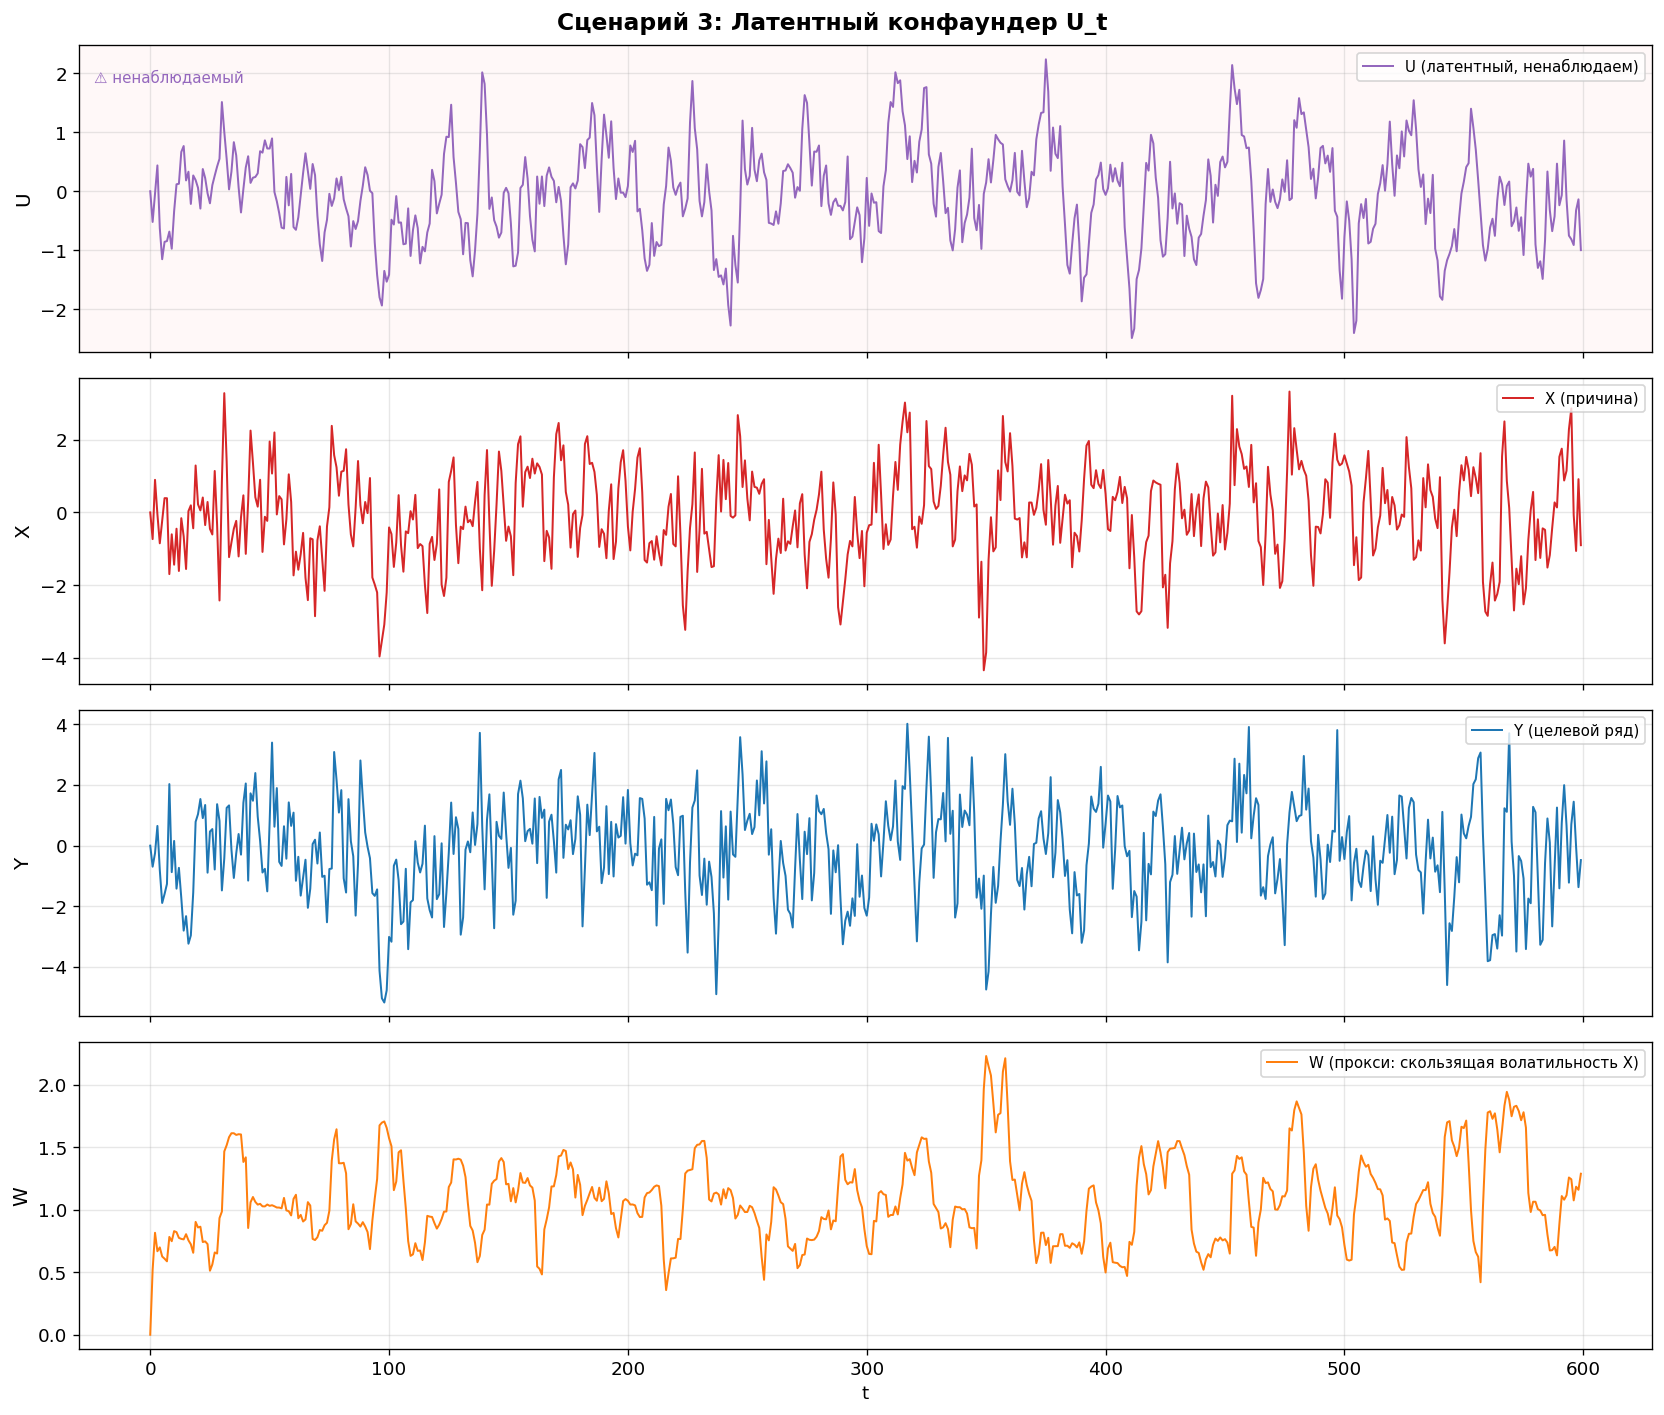

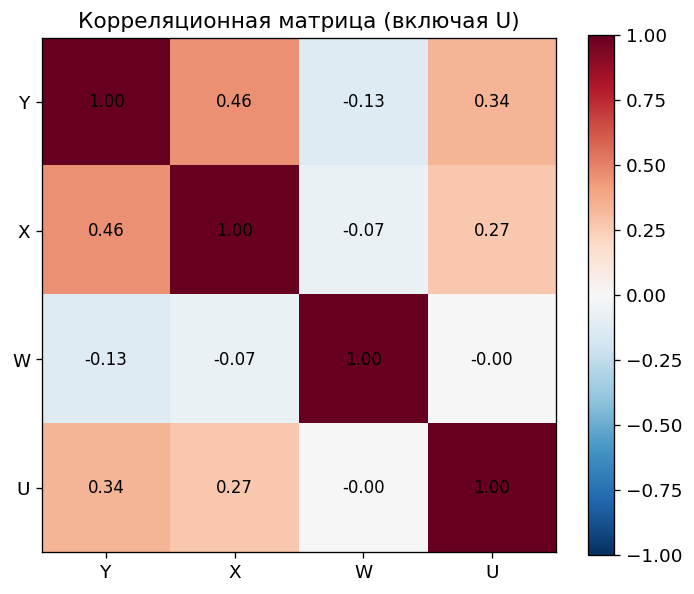


--- Иллюстрация смещения ---
  Истинный эффект (θ_true)   : 0.700
  Наивная оценка (без U)     : 0.880  → смещение = +0.180
  Оракульная оценка (с U)    : 0.831  → смещение = +0.131
  Оценка с прокси W          : 0.873  → смещение = +0.173


In [10]:
def plot_scenario3(res: dict):
    df_full = res['df_full']
    df_obs  = res['df_observed']

    fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
    fig.suptitle('Сценарий 3: Латентный конфаундер U_t', fontsize=14, fontweight='bold')

    var_cfg = [
        ('U', '#9467bd', 'U (латентный, ненаблюдаем)', True),
        ('X', '#d62728', 'X (причина)', False),
        ('Y', '#1f77b4', 'Y (целевой ряд)', False),
        ('W', '#ff7f0e', 'W (прокси: скользящая волатильность X)', False),
    ]

    for ax, (var, color, label, is_hidden) in zip(axes, var_cfg):
        ax.plot(df_full.index, df_full[var], color=color, lw=1.2, label=label)
        if is_hidden:
            ax.set_facecolor('#fff8f8')
            ax.text(0.01, 0.92, '⚠ ненаблюдаемый', transform=ax.transAxes,
                    color='#9467bd', fontsize=9, va='top')
        ax.set_ylabel(var, fontsize=12)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(alpha=0.3)

    axes[-1].set_xlabel('t')
    plt.tight_layout()
    plt.show()

    # Корреляционная матрица (наблюдаемые + латентный)
    fig2, ax2 = plt.subplots(figsize=(6, 5))
    corr = df_full.corr()
    im = ax2.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax2)
    labels = corr.columns.tolist()
    ax2.set_xticks(range(len(labels))); ax2.set_xticklabels(labels)
    ax2.set_yticks(range(len(labels))); ax2.set_yticklabels(labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax2.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=10)
    ax2.set_title('Корреляционная матрица (включая U)')
    plt.tight_layout()
    plt.show()

    # Смещение оценки без контроля U
    print('\n--- Иллюстрация смещения ---')
    from numpy.linalg import lstsq

    Y_arr = df_full['Y'].values[1:]
    X_lag = df_full['X'].values[:-1]
    U_arr = df_full['U'].values[1:]
    W_arr = df_obs['W'].values[1:]

    # Без контроля U
    coef_naive = lstsq(np.column_stack([X_lag, np.ones_like(X_lag)]), Y_arr, rcond=None)[0][0]

    # С контролем U (оракульная оценка)
    coef_oracle = lstsq(np.column_stack([X_lag, U_arr, np.ones_like(X_lag)]), Y_arr, rcond=None)[0][0]

    # С прокси W
    coef_proxy = lstsq(np.column_stack([X_lag, W_arr, np.ones_like(X_lag)]), Y_arr, rcond=None)[0][0]

    true = res['true_effect']
    print(f"  Истинный эффект (θ_true)   : {true:.3f}")
    print(f"  Наивная оценка (без U)     : {coef_naive:.3f}  → смещение = {coef_naive - true:+.3f}")
    print(f"  Оракульная оценка (с U)    : {coef_oracle:.3f}  → смещение = {coef_oracle - true:+.3f}")
    print(f"  Оценка с прокси W          : {coef_proxy:.3f}  → смещение = {coef_proxy - true:+.3f}")

plot_scenario3(res3)

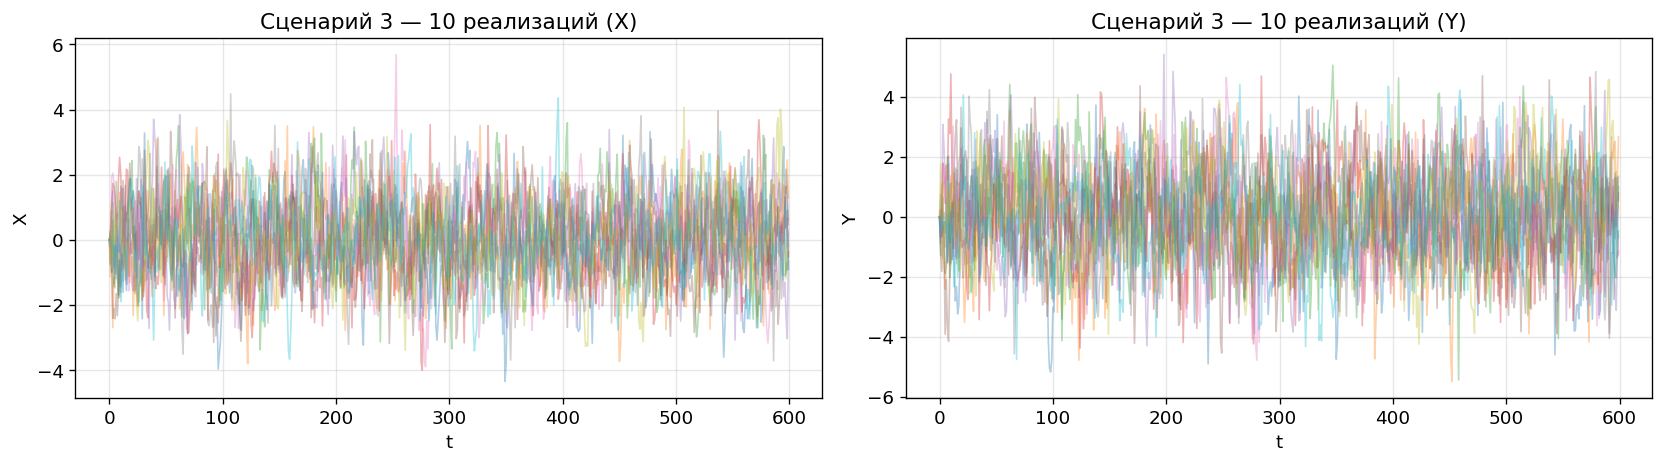

Сгенерировано 10 реализаций.


In [9]:
# Множественные реализации
realizations_s3 = [generate_scenario3(T=600, seed=GLOBAL_SEED + i) for i in range(10)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for r in realizations_s3:
    axes[0].plot(r['df_full'].index, r['df_full']['X'], alpha=0.35, lw=1)
    axes[1].plot(r['df_full'].index, r['df_full']['Y'], alpha=0.35, lw=1)
for ax, var in zip(axes, ['X', 'Y']):
    ax.set_title(f'Сценарий 3 — 10 реализаций ({var})')
    ax.set_xlabel('t'); ax.set_ylabel(var); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Сгенерировано {len(realizations_s3)} реализаций.')

---
## 4. Визуализация DAG-структур

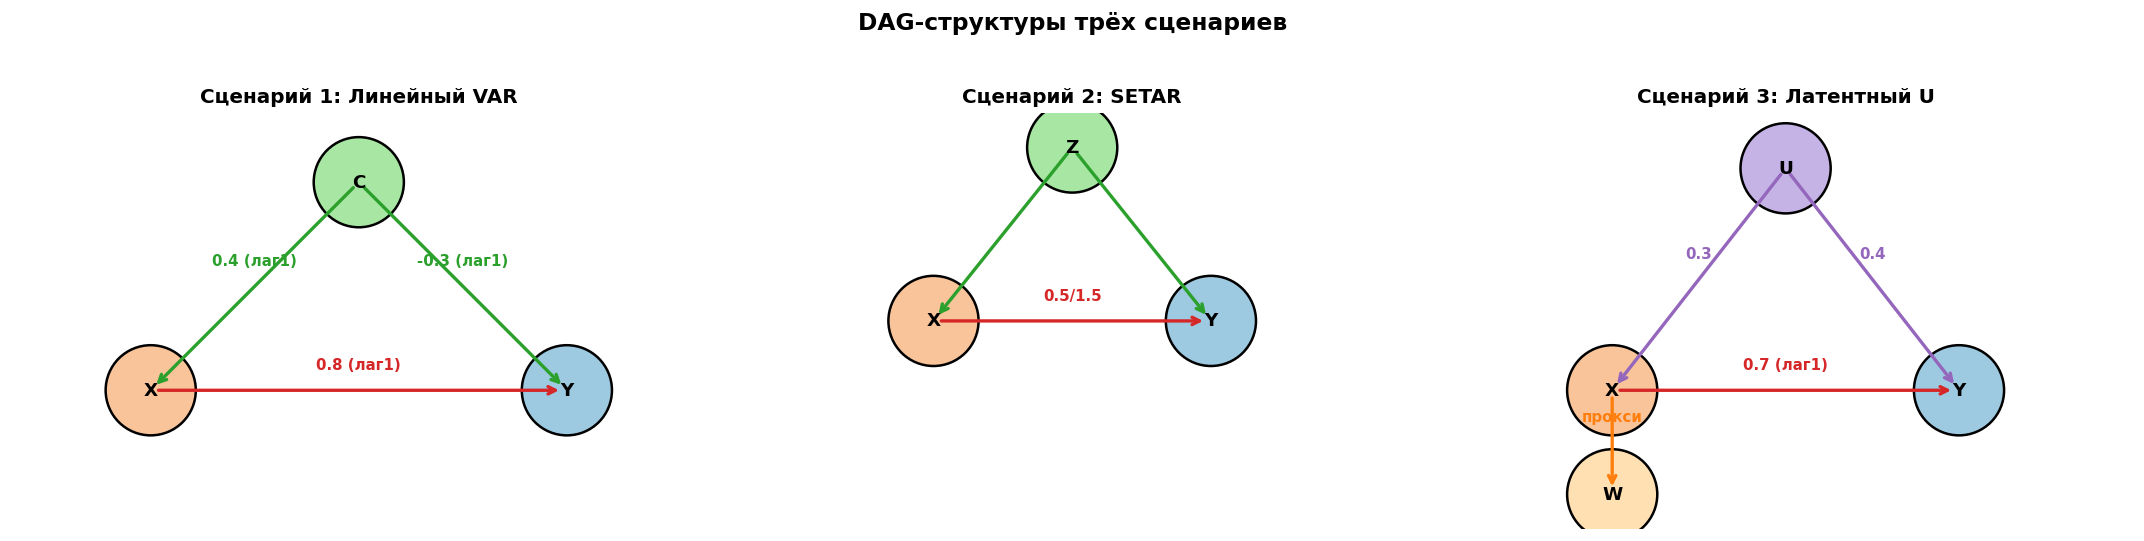

In [10]:
def draw_dag(ax, nodes: dict, edges: list, title: str):
    """
    Рисует DAG.
    nodes : {name: (x, y, color)}
    edges : [(from, to, label, color)]
    """
    ax.set_xlim(0, 10); ax.set_ylim(0, 6)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=12, fontweight='bold')

    node_radius = 0.65
    for name, (x, y, color) in nodes.items():
        circle = plt.Circle((x, y), node_radius, color=color, ec='black', lw=1.5, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, name, ha='center', va='center', fontsize=11,
                fontweight='bold', zorder=4)

    for (src, dst, label, ecolor) in edges:
        sx, sy, _ = nodes[src]
        dx, dy, _ = nodes[dst]
        ax.annotate('', xy=(dx, dy), xytext=(sx, sy),
                    arrowprops=dict(arrowstyle='->', lw=2, color=ecolor,
                                   shrinkA=node_radius*72/10,
                                   shrinkB=node_radius*72/10))
        mx, my = (sx+dx)/2, (sy+dy)/2
        ax.text(mx, my+0.25, label, ha='center', va='bottom', fontsize=9,
                color=ecolor, fontweight='bold')


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DAG-структуры трёх сценариев', fontsize=14, fontweight='bold')

# --- Сценарий 1 ---
nodes1 = {'C': (5, 5, '#a8e6a3'), 'X': (2, 2, '#f9c49a'), 'Y': (8, 2, '#9ecae1')}
edges1 = [
    ('C', 'X', '0.4 (лаг1)', '#2ca02c'),
    ('C', 'Y', '-0.3 (лаг1)', '#2ca02c'),
    ('X', 'Y', '0.8 (лаг1)', '#d62728'),
]
draw_dag(axes[0], nodes1, edges1, 'Сценарий 1: Линейный VAR')

# --- Сценарий 2 ---
nodes2 = {'X': (3, 3, '#f9c49a'), 'Z': (5, 5.5, '#a8e6a3'), 'Y': (7, 3, '#9ecae1')}
edges2 = [
    ('X', 'Y', '0.5/1.5', '#d62728'),
    ('Z', 'X', '', '#2ca02c'),
    ('Z', 'Y', '', '#2ca02c'),
]
draw_dag(axes[1], nodes2, edges2, 'Сценарий 2: SETAR')

# --- Сценарий 3 ---
nodes3 = {'U': (5, 5.2, '#c5b3e6'), 'X': (2.5, 2, '#f9c49a'), 'Y': (7.5, 2, '#9ecae1'), 'W': (2.5, 0.5, '#ffe0b3')}
edges3 = [
    ('U', 'X', '0.3', '#9467bd'),
    ('U', 'Y', '0.4', '#9467bd'),
    ('X', 'Y', '0.7 (лаг1)', '#d62728'),
    ('X', 'W', 'прокси', '#ff7f0e'),
]
draw_dag(axes[2], nodes3, edges3, 'Сценарий 3: Латентный U')

plt.tight_layout()
plt.show()

---
## 6. Сохранение данных

In [14]:
import os

OUTPUT_DIR = 'synthetic_data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Сценарий 1: все 10 реализаций ---
for i, r in enumerate(realizations_s1):
    r['df'].to_csv(f'{OUTPUT_DIR}/scenario1_realization_{i+1:02d}.csv')
    r['df_counterfactual'].to_csv(f'{OUTPUT_DIR}/scenario1_realization_{i+1:02d}_counterfactual.csv')

# --- Сценарий 2 ---
for i, r in enumerate(realizations_s2):
    r['df'].to_csv(f'{OUTPUT_DIR}/scenario2_realization_{i+1:02d}.csv')

# --- Сценарий 3 (только наблюдаемые переменные) ---
for i, r in enumerate(realizations_s3):
    r['df_observed'].to_csv(f'{OUTPUT_DIR}/scenario3_realization_{i+1:02d}_observed.csv')
    r['df_full'].to_csv(f'{OUTPUT_DIR}/scenario3_realization_{i+1:02d}_full.csv')  # с U

# --- Метаданные ---
meta = {
    'scenario': [1, 2, 3],
    'description': [
        'Linear VAR with confouncer C',
        'Nonlinear SETAR with threshold effect',
        'Latent confounder U with proxy W',
    ],
    'true_effect': [
        realizations_s1[0]['true_effect'],
        f"{realizations_s2[0]['beta_low']} (low) / {realizations_s2[0]['beta_high']} (high)",
        realizations_s3[0]['true_effect'],
    ],
    'n_realizations': [10, 10, 10],
    'T': [600, 600, 600],
}
pd.DataFrame(meta).to_csv(f'{OUTPUT_DIR}/metadata.csv', index=False)

print('Файлы сохранены в папку:', OUTPUT_DIR)
print('Структура:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  {f}')

Файлы сохранены в папку: synthetic_data
Структура:
  metadata.csv
  scenario1_realization_01.csv
  scenario1_realization_01_counterfactual.csv
  scenario1_realization_02.csv
  scenario1_realization_02_counterfactual.csv
  scenario1_realization_03.csv
  scenario1_realization_03_counterfactual.csv
  scenario1_realization_04.csv
  scenario1_realization_04_counterfactual.csv
  scenario1_realization_05.csv
  scenario1_realization_05_counterfactual.csv
  scenario1_realization_06.csv
  scenario1_realization_06_counterfactual.csv
  scenario1_realization_07.csv
  scenario1_realization_07_counterfactual.csv
  scenario1_realization_08.csv
  scenario1_realization_08_counterfactual.csv
  scenario1_realization_09.csv
  scenario1_realization_09_counterfactual.csv
  scenario1_realization_10.csv
  scenario1_realization_10_counterfactual.csv
  scenario2_realization_01.csv
  scenario2_realization_02.csv
  scenario2_realization_03.csv
  scenario2_realization_04.csv
  scenario2_realization_05.csv
  scenari

---
## 7. Сводная таблица параметров и истинных эффектов

In [15]:
summary = pd.DataFrame([
    {
        'Сценарий': '1: Линейный VAR',
        'Переменные': 'Y, X, C',
        'Истинный θ': '0.8',
        'Конфаундер': 'C (наблюдаем)',
        'Нелинейность': 'Нет',
        'Вмешательство': f't₀={res1["t0"]}, Δ={res1["delta"]:.2f}',
    },
    {
        'Сценарий': '2: SETAR (пороговый)',
        'Переменные': 'Y, X, Z, vol_X',
        'Истинный θ': '0.5 / 1.5',
        'Конфаундер': 'Z (наблюдаем)',
        'Нелинейность': 'Пороговая',
        'Вмешательство': 'Нет',
    },
    {
        'Сценарий': '3: Латентный конфаундер',
        'Переменные': 'Y, X, W (U — скрыт)',
        'Истинный θ': '0.7',
        'Конфаундер': 'U (латентный)',
        'Нелинейность': 'Нет',
        'Вмешательство': 'Нет',
    },
])

summary.set_index('Сценарий', inplace=True)
print('Сводная таблица сценариев:')
summary

Сводная таблица сценариев:


,Переменные,Истинный θ,Конфаундер,Нелинейность,Вмешательство
Сценарий,,,,,
1: Линейный VAR,"Y, X, C",0.8,C (наблюдаем),Нет,"t₀=300, Δ=2.55"
2: SETAR (пороговый),"Y, X, Z, vol_X",0.5 / 1.5,Z (наблюдаем),Пороговая,Нет
3: Латентный конфаундер,"Y, X, W (U — скрыт)",0.7,U (латентный),Нет,Нет
